In [1]:
import numpy as np
import networkx as nx
import mesa
import matplotlib.pyplot as plt
from enum import Enum
from mesa import Model, Agent
from mesa.space import NetworkGrid
from mesa.datacollection import DataCollector

In [2]:
class State(Enum):
    NON_SUSTAINABLE = 0
    TRANSITIONING = 1
    SUSTAINABLE = 2

In [3]:
class HouseholdAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        
        self.state = State.NON_SUSTAINABLE
        
        # Behavioral traits
        self.susceptibility = self.random.uniform(0.3, 1.0)   # openness--> fewer adopters then slower stransition
        self.entitlement = self.random.uniform(0.0, 1.0)      # resistance
        # -- We could use this one insead, making elites more resistant which is very relevant for high-income households
        # if self.model.G.degree[self.pos] > 10:
            #self.entitlement = 0.8
        self.habit = self.random.uniform(0.0, 1.0)            # inertia, if increased then system becomes sticky and harder to change
        

    def step(self):
        if self.state == State.NON_SUSTAINABLE:
            self.try_to_transition()
        elif self.state == State.TRANSITIONING:
            self.try_to_stabilize()

    # --- KEY FUNCTION ---
    def try_to_transition(self):
        neighbors = self.model.grid.get_neighbors(self.pos)
        if len(neighbors) == 0:
            return
        
        sustainable_neighbors = sum(1 for n in neighbors if n.state == State.SUSTAINABLE)
        
        social_norm = sustainable_neighbors / len(neighbors)

        # Adoption probability
        prob = (self.model.beta * social_norm * self.susceptibility * (1 - self.entitlement) * (1 - self.habit))

        if self.random.random() < prob:
            self.state = State.TRANSITIONING

    def try_to_stabilize(self):
        # chance to become fully sustainable
        stabilize_prob = self.model.gamma * (1 - self.habit)

        if self.random.random() < stabilize_prob:
            self.state = State.SUSTAINABLE

In [4]:
class AdoptionModel(Model):
    def __init__(self, N=100, beta=0.3, gamma=0.1):
        super().__init__()
        
        self.beta = beta      # strength of social norms
        self.gamma = gamma    # stabilization probability
        self.time = 0

        # --- Network ---
        self.G = nx.barabasi_albert_graph(N, 3)
        # type of network that has few elite hubs and many low nodes. We could try others like:
        # self.G = nx.erdos_renyi_graph(N, 0.1) #--> random society
        # self.G = nx.watts_strogatz_graph(N, 4, 0.1) #--> clustered communities where social norms gain importance
        self.grid = NetworkGrid(self.G)

        # --- Agent storage (Mesa 3 compatible) ---
        self.agent_list = []

        # --- Create agents ---
        for node in self.G.nodes():
            agent = HouseholdAgent(self)
            self.agent_list.append(agent)
            self.grid.place_agent(agent, node)

        # --- Initial condition: seed sustainable behavior ---
        initial_agents = np.random.choice(self.agent_list, size=5, replace=False)
        for agent in initial_agents:
            agent.state = State.SUSTAINABLE

        # --- Data collection ---
        self.datacollector = DataCollector(
            model_reporters={
                "Sustainable": lambda m: sum(a.state == State.SUSTAINABLE for a in m.agent_list),
                "Transitioning": lambda m: sum(a.state == State.TRANSITIONING for a in m.agent_list),
                "Non Sustainable": lambda m: sum(a.state == State.NON_SUSTAINABLE for a in m.agent_list),
            }
        )

    def step(self):
        # -- INCLUDE POLYCY SHOCK
        # if self.time == 10:
            #self.beta = 0   # stronger social pressure (e.g. campaign, regulation)
        # you can also modify other things here
        
        # Collect data
        self.datacollector.collect(self)

        # Random activation
        np.random.shuffle(self.agent_list)

        for agent in self.agent_list:
            agent.step()

        self.time += 1

In [5]:
model = AdoptionModel(N=200, beta=0.25, gamma=0.05)
# change beta--> social pressure, low = no adoption, high = adoption
# change gamma--> stabilization, low = people stay transitioning, high = fast transition

for _ in range(100):
    model.step()

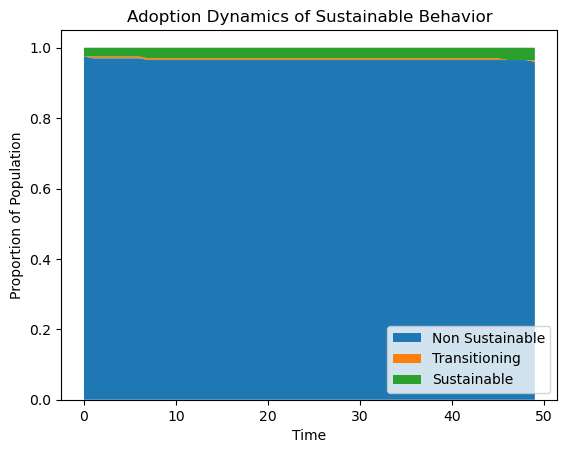

In [6]:
df = model.datacollector.get_model_vars_dataframe()

# Normalize
df_norm = df.div(df.sum(axis=1), axis=0)

# Stackplot
plt.figure()

plt.stackplot(
    df_norm.index,
    df_norm["Non Sustainable"],
    df_norm["Transitioning"],
    df_norm["Sustainable"],
    labels=["Non Sustainable", "Transitioning", "Sustainable"]
)

plt.xlabel("Time")
plt.ylabel("Proportion of Population")
plt.title("Adoption Dynamics of Sustainable Behavior")
plt.legend(loc="lower right")

plt.show()